# Baseline Dissimilarity Matrix

## Set Up Environment

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.spatial

from scenario2_utils import (
    compute_adp_dissimilarity_matrix,
    compute_geodesic_dissimilarity_matrix,
    load_dataset_artifacts,
    plot_dissimilarity_over_euclidean_distance,
    scale_dissimilarity_matrix_to_meters,
 )

## Load Data

In [2]:
dataset = load_dataset_artifacts()
csi_freq_domain_train = dataset.csi_freq_domain_train
groundtruth_positions_train = dataset.groundtruth_positions_train

print("Shape of csi_freq_domain_train: ", csi_freq_domain_train.shape)
print("Shape of groundtruth_positions_train: ", groundtruth_positions_train.shape)

Shape of csi_freq_domain_train:  (5000, 5, 4, 2, 4, 64)
Shape of groundtruth_positions_train:  (5000, 3)


### Prepare CSI Metric Input

In [3]:
#csi_time_domain_train = np.fft.fftshift(np.fft.ifft(np.fft.fftshift(csi_freq_domain_train, axes = -1)), axes=-1)#[...,27:40]
#csi_time_domain_train.shape

In [4]:
csi_metric_input = csi_freq_domain_train

In [5]:
csi_metric_input = csi_metric_input.reshape((csi_metric_input.shape[0], -1, csi_metric_input.shape[3], csi_metric_input.shape[4], csi_metric_input.shape[5]))
csi_metric_input.shape

(5000, 20, 2, 4, 64)

## Compute Dissimilarity Matrices

### Compute ADP Dissimilarities

In [6]:
adp_dissimilarity_matrix = compute_adp_dissimilarity_matrix(csi_metric_input)

100%|██████████| 25000000/25000000 [03:09<00:00, 131689.73it/s]


### Compute Geodesic Dissimilarities

In [7]:
n_neighbors = 20

In [8]:
dissimilarity_matrix_geodesic = compute_geodesic_dissimilarity_matrix(
    adp_dissimilarity_matrix,
    n_neighbors=n_neighbors,
 )

In [9]:
np.save("results/dissimilarity_matrix_geodesic.npy", dissimilarity_matrix_geodesic)

## Scale the Dissimilarity Matrix
All values should be in meters.

In [10]:
dissimilarity_matrix_geodesic_meters = scale_dissimilarity_matrix_to_meters(
    dissimilarity_matrix_geodesic,
    groundtruth_positions_train,
    reduction=30,
 )

In [11]:
np.save("results/dissimilarity_matrix_geodesic_meters.npy", dissimilarity_matrix_geodesic_meters)

## Visualize the Dissimilarity Matrix

In [12]:
# Compute distances between groundtruth positions
groundtruth_distance_matrix = scipy.spatial.distance_matrix(groundtruth_positions_train, groundtruth_positions_train)

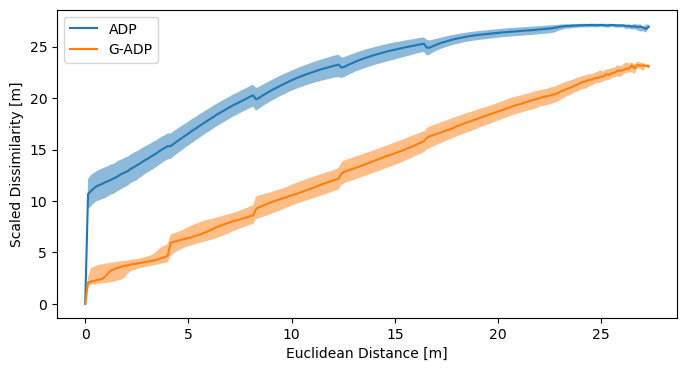

In [13]:
plt.figure(figsize=(8, 4))

scaling_factor = np.max(groundtruth_distance_matrix) / np.max(adp_dissimilarity_matrix)

plot_dissimilarity_over_euclidean_distance(
    scaling_factor * adp_dissimilarity_matrix,
    groundtruth_distance_matrix,
    "ADP",
 )
plot_dissimilarity_over_euclidean_distance(
    dissimilarity_matrix_geodesic_meters,
    groundtruth_distance_matrix,
    "G-ADP",
 )

plt.legend()
plt.xlabel("Euclidean Distance [m]")
plt.ylabel("Scaled Dissimilarity [m]")
plt.show()